### Cleaning & Integration (Deliverable A)



### Setup


In [47]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("..")
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

trips = pd.read_csv(RAW / "ride_demand_train.csv")
weather = pd.read_csv(RAW / "weather_hourly.csv")
events = pd.read_csv(RAW / "events_calendar.csv")

print("Loaded:", trips.shape, weather.shape, events.shape)

Loaded: (85460, 7) (7538, 6) (165, 9)


In [48]:
trips.head()

,record_id,zone,pickup_hour,trips,avg_fare_birr,avg_wait_min,active_drivers
0,R-000001,Kazanchis,2025-06-26 11:00,27.0,275.1,2.1,22
1,R-000002,PIASSA,16/08/2025 04:00,2.0,242.8,1.2,3
2,R-000003,Piassa,2025-10-17 11:00,19.0,256.5,1.5,16
3,R-000004,Gerji,2025-01-09 18:00,39.0,275.2,3.0,27
4,R-000005,ayat,2025-05-24 03:00,5.0,325.2,1.4,6


In [49]:
weather.head()

,timestamp,temp_c,rain_mm,humidity_pct,wind_kmh,data_type
0,2024-12-30T21:00:00Z,10.8,0.0,84.0,10.2,observed
1,2024-12-30T22:00:00Z,9.9,0.0,100.0,5.5,observed
2,2024-12-30T23:00:00Z,8.8,0.0,93.0,11.3,observed
3,2024-12-31T00:00:00Z,9.3,0.0,92.0,9.1,observed
4,2024-12-31T01:00:00Z,9.7,0.0,91.0,4.3,observed


In [50]:
events.head()

,event_id,event_name,event_type,venue,zone,start_datetime,end_datetime,expected_attendance,status
0,EVT-0014,Premier league match,football_match,Addis Ababa Stadium,Kazanchis (Kirkos),06/02/2025 18:00,"Feb 06, 2025 08:00 PM",approx 34000,confirmed
1,EVT-0081,Road closure (construction),Road closure,NaN,AYAT,2025-06-07 08:00,07/06/2025 18:00,NaN,confirmed
2,EVT-0106,Premier league match,football_match,Addis Ababa Stadium,Kazanchis,13/08/2025 19:00,2025-08-13 21:00,30930,confirmed
3,EVT-0069,Road closure (construction),road closure,NaN,cmc,"May 14, 2025 01:00 PM",2025-05-15 03:00,NaN,confirmed
4,EVT-0045,Good Friday,public_holiday,NaN,Citywide,18/04/2025 00:00,"Apr 18, 2025 11:59 PM",NaN,Confirmed


### A1 — Cleaning log

One table, one row per issue: file, column(s), issue type, rows affected (count and %), fix applied, and why.

**Method:** run EDA on each raw file first (evidence below), then summarize into the cleaning-log table at the end of this section. Cover all three tables — at least 5 distinct issues in trips, 4 in weather, and 4 in events.


### Trip file (raw)

Discover data-quality issues **before** cleaning. Each subsection shows the problem with count and %.


In [51]:
# Overview: shape, dtypes, missingness
n_trips = len(trips)
print("shape:", trips.shape)
print("\ndtypes:")
print(trips.dtypes)
print("\nmissing values:")
miss = trips.isna().sum().to_frame("count")
miss["pct"] = (miss["count"] / n_trips * 100).round(2)
miss

shape: (85460, 7)

dtypes:
record_id             str
zone                  str
pickup_hour           str
trips             float64
avg_fare_birr     float64
avg_wait_min      float64
active_drivers      int64
dtype: object

missing values:


,count,pct
record_id,0,0.00
zone,0,0.00
pickup_hour,0,0.00
trips,845,0.99
avg_fare_birr,1277,1.49
avg_wait_min,0,0.00
active_drivers,0,0.00


#### Issue 1 — Inconsistent zone labels

Expect 12 zones; raw file has many spellings / case / whitespace variants.


In [52]:
zone_vc = trips["zone"].value_counts()
print(f"distinct raw zone labels: {trips['zone'].nunique()} (expected ~12)")
print(f"rows affected: {n_trips} (100%) — every row uses a label that may need mapping")
print("\nall raw labels:")
zone_vc

distinct raw zone labels: 55 (expected ~12)
rows affected: 85460 (100%) — every row uses a label that may need mapping

all raw labels:


zone
Megenagna        4593
Piassa           4563
CMC              4559
Kazanchis        4550
Gerji            4523
Lideta           4514
Bole             4507
Arat Kilo        4506
Merkato          4470
Kolfe            4456
Sarbet           4446
Ayat             3382
CMC               945
Sarbet            945
Lideta            944
sarbet            939
SARBET            925
gerji             924
GERJI             915
LIDETA            912
lideta            906
Gerji             906
cmc               886
C.M.C             880
MERKATO           753
ayat              729
arat kilo         729
Kolfe             726
Ayat              721
PIASSA            718
kolfe             714
Bole              710
piassa            707
Arat  Kilo        705
KAZANCHIS         704
Megenagna         701
merkato           697
kazanchis         694
Bole Rd           689
bole              689
KOLFE             688
Merkato           686
Kolfe Keranio     681
ARAT KILO         677
AYAT              675
BOLE 

#### Issue 2 — Mixed `pickup_hour` datetime formats

Slash (day-first), ISO space, and ISO-T with `+03:00` coexist. Wrong parse order flips day/month.


In [53]:
ph = trips["pickup_hour"].astype(str)
fmt = pd.Series("other", index=trips.index)
fmt = fmt.mask(ph.str.match(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}$"), "iso_space")
fmt = fmt.mask(ph.str.contains(r"T.*\+03:00"), "iso_T_plus03")
fmt = fmt.mask(ph.str.contains("/"), "slash_dmy")

fmt_summary = (
    fmt.value_counts()
    .rename_axis("format")
    .to_frame("count")
    .assign(pct=lambda d: (d["count"] / n_trips * 100).round(2))
)
print("format mix (all rows have a timestamp string):")
display(fmt_summary)
print("examples:")
for name in fmt_summary.index:
    print(f"  {name}:", ph[fmt == name].iloc[0])

format mix (all rows have a timestamp string):


,count,pct
format,,
iso_space,46886,54.86
slash_dmy,25764,30.15
iso_T_plus03,12810,14.99


examples:
  iso_space: 2025-06-26 11:00
  slash_dmy: 16/08/2025 04:00
  iso_T_plus03: 2025-05-27T23:00:00+03:00


#### Issue 3 — Missing `trips` (target)


In [54]:
miss_trips = int(trips["trips"].isna().sum())
print(f"missing trips: {miss_trips} rows ({miss_trips / n_trips * 100:.2f}%)")
trips.loc[trips["trips"].isna(), ["record_id", "zone", "pickup_hour", "trips"]].head()

missing trips: 845 rows (0.99%)


,record_id,zone,pickup_hour,trips
75,R-000076,Piassa,2025-01-29 02:00,NaN
178,R-000179,Kazanchis,2025-03-06 18:00,NaN
526,R-000527,lideta,2025-01-15 03:00,NaN
572,R-000573,LIDETA,2025-07-12 20:00,NaN
579,R-000580,KOLFE,2025-07-05 17:00,NaN


#### Issue 4 — Impossible negative `trips`


In [55]:
neg_trips = trips["trips"] < 0
n_neg_trips = int(neg_trips.sum())
print(f"negative trips: {n_neg_trips} rows ({n_neg_trips / n_trips * 100:.2f}%)")
print("unique negative values:", sorted(trips.loc[neg_trips, "trips"].dropna().unique().tolist()))
trips.loc[neg_trips, ["record_id", "zone", "pickup_hour", "trips"]].head()

negative trips: 681 rows (0.80%)
unique negative values: [-1.0]


,record_id,zone,pickup_hour,trips
32,R-000033,piassa,30/06/2025 19:00,-1.0
149,R-000150,ayat,2025-06-06T08:00:00+03:00,-1.0
155,R-000156,Merkato,2025-01-22T05:00:00+03:00,-1.0
330,R-000331,Piassa,14/06/2025 21:00,-1.0
472,R-000473,Megenagna,10/02/2025 21:00,-1.0


#### Issue 5 — Impossible negative `avg_wait_min`


In [56]:
neg_wait = trips["avg_wait_min"] < 0
n_neg_wait = int(neg_wait.sum())
print(f"negative avg_wait_min: {n_neg_wait} rows ({n_neg_wait / n_trips * 100:.2f}%)")
print("unique negative values:", sorted(trips.loc[neg_wait, "avg_wait_min"].unique().tolist()))
trips.loc[neg_wait, ["record_id", "zone", "pickup_hour", "avg_wait_min"]].head()

negative avg_wait_min: 1707 rows (2.00%)
unique negative values: [-1.0]


,record_id,zone,pickup_hour,avg_wait_min
56,R-000057,sarbet,27/04/2025 21:00,-1.0
61,R-000062,Gerji,2025-09-30 19:00,-1.0
108,R-000109,Bole Rd,22/02/2025 11:00,-1.0
116,R-000117,piassa,2025-02-25T08:00:00+03:00,-1.0
120,R-000121,Gerji,2025-09-09 07:00,-1.0


#### Issue 6 — Missing `avg_fare_birr`


In [57]:
miss_fare = int(trips["avg_fare_birr"].isna().sum())
print(f"missing avg_fare_birr: {miss_fare} rows ({miss_fare / n_trips * 100:.2f}%)")
trips.loc[trips["avg_fare_birr"].isna(), ["record_id", "zone", "pickup_hour", "avg_fare_birr"]].head()

missing avg_fare_birr: 1277 rows (1.49%)


,record_id,zone,pickup_hour,avg_fare_birr
9,R-000010,Bole,18/07/2025 03:00,NaN
70,R-000071,CMC,18/08/2025 08:00,NaN
121,R-000122,Bole,2025-07-29 20:00,NaN
200,R-000201,Ayat,17/08/2025 18:00,NaN
328,R-000329,Kolfe,2025-08-01T05:00:00+03:00,NaN


#### Issue 7 — Duplicate zone–hour keys (after soft normalize)

Same zone+hour appears more than once once labels/times are lightly normalized — breaks joins and can inflate demand.


In [58]:
from datetime import datetime


def _parse_pickup_hour(s: str):
    for fmt in ("%Y-%m-%d %H:%M", "%d/%m/%Y %H:%M", "%Y-%m-%dT%H:%M:%S%z"):
        try:
            dt = datetime.strptime(s, fmt)
            if dt.tzinfo is not None:
                dt = dt.replace(tzinfo=None)  # already +03:00 local
            return dt
        except ValueError:
            continue
    return pd.NaT


z_soft = trips["zone"].astype(str).str.strip().str.lower().str.replace(r"\s+", " ", regex=True)
t_parsed = pd.to_datetime(ph.map(_parse_pickup_hour))
trip_keys = trips.assign(zone_soft=z_soft, pickup_hour_parsed=t_parsed)

print("unparsed timestamps:", int(trip_keys["pickup_hour_parsed"].isna().sum()))
print("soft-normalized zone labels:", trip_keys["zone_soft"].nunique())

dup_mask = trip_keys.duplicated(subset=["zone_soft", "pickup_hour_parsed"], keep=False)
extra = int(trip_keys.duplicated(subset=["zone_soft", "pickup_hour_parsed"], keep="first").sum())
n_dup_rows = int(dup_mask.sum())
print(f"rows in duplicate keys: {n_dup_rows} ({n_dup_rows / n_trips * 100:.2f}%)")
print(f"extra rows beyond first key: {extra} ({extra / n_trips * 100:.2f}%)")

trip_keys.loc[
    dup_mask, ["record_id", "zone", "zone_soft", "pickup_hour", "pickup_hour_parsed", "trips"]
].sort_values(["zone_soft", "pickup_hour_parsed"]).head(8)

unparsed timestamps: 0
soft-normalized zone labels: 19
rows in duplicate keys: 1524 (1.78%)
extra rows beyond first key: 762 (0.89%)


,record_id,zone,zone_soft,pickup_hour,pickup_hour_parsed,trips
31065,R-031066,Arat Kilo,arat kilo,06/01/2025 22:00,2025-01-06 22:00:00,7.0
85279,R-085280,arat kilo,arat kilo,2025-01-06 22:00,2025-01-06 22:00:00,7.0
48428,R-048429,Arat Kilo,arat kilo,2025-01-09T04:00:00+03:00,2025-01-09 04:00:00,3.0
73846,R-073847,Arat Kilo,arat kilo,2025-01-09 04:00,2025-01-09 04:00:00,2.0
27625,R-027626,arat kilo,arat kilo,17/01/2025 22:00,2025-01-17 22:00:00,7.0
50826,R-050827,Arat Kilo,arat kilo,17/01/2025 22:00,2025-01-17 22:00:00,6.0
26279,R-026280,Arat Kilo,arat kilo,2025-02-03 06:00,2025-02-03 06:00:00,16.0
85396,R-085397,Arat Kilo,arat kilo,2025-02-03 06:00,2025-02-03 06:00:00,16.0


#### Trips — issues found (evidence only; fixes later)

| # | column(s) | issue | rows (count / %) |
|---|-----------|-------|------------------|
| 1 | `zone` | inconsistent spelling / case / whitespace | 55 raw labels; all rows need canonical mapping |
| 2 | `pickup_hour` | mixed datetime formats | ~30% slash DMY, ~55% ISO space, ~15% ISO-T+03 |
| 3 | `trips` | missing target | 845 / 0.99% |
| 4 | `trips` | impossible negatives (`-1`) | 681 / 0.80% |
| 5 | `avg_wait_min` | impossible negatives (`-1`) | 1,707 / 2.00% |
| 6 | `avg_fare_birr` | missing values | 1,277 / 1.49% |
| 7 | `zone`, `pickup_hour` | duplicate zone–hour after soft normalize | 1,524 rows in dup keys / 1.78% (762 extras) |

Next: **weather** file, then **events**, then the cleaning-log table.


### Weather file (raw)

Discover data-quality issues **before** cleaning. Each subsection shows the problem with count and %.


In [59]:
# Overview: shape, dtypes, missingness
n_weather = len(weather)
print("shape:", weather.shape)
print("\ndtypes:")
print(weather.dtypes)
print("\nmissing values:")
miss_w = weather.isna().sum().to_frame("count")
miss_w["pct"] = (miss_w["count"] / n_weather * 100).round(2)
display(miss_w)
print("\ndata_type:")
print(weather["data_type"].value_counts())


shape: (7538, 6)

dtypes:
timestamp           str
temp_c          float64
rain_mm         float64
humidity_pct    float64
wind_kmh        float64
data_type           str
dtype: object

missing values:


,count,pct
timestamp,0,0.00
temp_c,42,0.56
rain_mm,0,0.00
humidity_pct,153,2.03
wind_kmh,0,0.00
data_type,0,0.00



data_type:
data_type
observed    7204
forecast     334
Name: count, dtype: int64


#### Issue W1 — Mixed `timestamp` clocks/formats

Most rows are ISO UTC (`...Z`); others are slash day-first **local** times. Joining without converting clocks misaligns hours.


In [60]:
w_ts = weather["timestamp"].astype(str)
w_fmt = pd.Series("other", index=weather.index)
w_fmt = w_fmt.mask(w_ts.str.endswith("Z"), "iso_Z_utc")
w_fmt = w_fmt.mask(w_ts.str.contains("/"), "slash_dmy_local")

w_fmt_summary = (
    w_fmt.value_counts()
    .rename_axis("format")
    .to_frame("count")
    .assign(pct=lambda d: (d["count"] / n_weather * 100).round(2))
)
print("timestamp format mix:")
display(w_fmt_summary)
print("examples:")
for name in w_fmt_summary.index:
    print(f"  {name}:", w_ts[w_fmt == name].iloc[0])


timestamp format mix:


,count,pct
format,,
iso_Z_utc,6806,90.29
slash_dmy_local,732,9.71


examples:
  iso_Z_utc: 2024-12-30T21:00:00Z
  slash_dmy_local: 31/12/2024 15:00


#### Issue W2 — Sentinel missing rain (`rain_mm == -9999`)


In [61]:
rain_sentinel = weather["rain_mm"] == -9999
n_rain_sent = int(rain_sentinel.sum())
print(f"rain_mm == -9999: {n_rain_sent} rows ({n_rain_sent / n_weather * 100:.2f}%)")
print("rain_mm describe (raw — mean dragged by sentinel):")
print(weather["rain_mm"].describe())
weather.loc[rain_sentinel, ["timestamp", "rain_mm", "temp_c", "data_type"]].head()


rain_mm == -9999: 76 rows (1.01%)
rain_mm describe (raw — mean dragged by sentinel):
count    7538.000000
mean     -100.564473
std       999.021666
min     -9999.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.700000
Name: rain_mm, dtype: float64


,timestamp,rain_mm,temp_c,data_type
16,2024-12-31T14:00:00Z,-9999.0,21.8,observed
24,2024-12-31T22:00:00Z,-9999.0,8.0,observed
117,2025-01-04T17:00:00Z,-9999.0,15.3,observed
135,2025-01-05T11:00:00Z,-9999.0,19.2,observed
160,2025-01-06T10:00:00Z,-9999.0,20.8,observed


#### Issue W3 — Fahrenheit mixed into `temp_c`

Addis rarely exceeds ~35°C. Values in the 50–80 band look like °F stored in a °C column.


In [62]:
f_like = weather["temp_c"].between(50, 80)
n_f = int(f_like.sum())
print(f"temp_c in [50, 80]: {n_f} rows ({n_f / n_weather * 100:.2f}%)")
print(f"temp_c null: {int(weather['temp_c'].isna().sum())} ({weather['temp_c'].isna().mean()*100:.2f}%)")
print("temp_c describe:")
print(weather["temp_c"].describe())
weather.loc[f_like, ["timestamp", "temp_c", "humidity_pct", "data_type"]].head()


temp_c in [50, 80]: 353 rows (4.68%)
temp_c null: 42 (0.56%)
temp_c describe:
count    7496.000000
mean       19.191729
std        10.907241
min         5.400000
25%        13.700000
50%        17.200000
75%        20.900000
max        76.600000
Name: temp_c, dtype: float64


,timestamp,temp_c,humidity_pct,data_type
4539,2025-07-10T00:00:00Z,57.4,83.0,observed
4540,2025-07-10T01:00:00Z,59.5,79.0,observed
4541,2025-07-10T02:00:00Z,60.4,83.0,observed
4542,2025-07-10T03:00:00Z,61.2,83.0,observed
4543,2025-07-10T04:00:00Z,61.7,75.0,observed


#### Issue W4 — Missing `temp_c` / `humidity_pct` readings


In [63]:
miss_temp = weather["temp_c"].isna()
miss_hum = weather["humidity_pct"].isna()
miss_either = miss_temp | miss_hum
print(f"temp_c null: {int(miss_temp.sum())} ({miss_temp.mean()*100:.2f}%)")
print(f"humidity_pct null: {int(miss_hum.sum())} ({miss_hum.mean()*100:.2f}%)")
print(f"rows missing temp and/or humidity: {int(miss_either.sum())} ({miss_either.mean()*100:.2f}%)")
weather.loc[miss_either, ["timestamp", "temp_c", "humidity_pct", "rain_mm", "data_type"]].head()


temp_c null: 42 (0.56%)
humidity_pct null: 153 (2.03%)
rows missing temp and/or humidity: 195 (2.59%)


,timestamp,temp_c,humidity_pct,rain_mm,data_type
60,2025-01-02T10:00:00Z,20.2,NaN,0.0,observed
100,2025-01-04T01:00:00Z,8.1,NaN,0.0,observed
101,2025-01-04T01:00:00Z,9.4,NaN,0.0,observed
108,04/01/2025 08:00,17.4,NaN,0.0,observed
119,2025-01-04T19:00:00Z,12.4,NaN,0.0,observed


#### Issue W5 — Duplicate hours after UTC → Africa/Addis_Ababa

Slash timestamps appear local; `...Z` are UTC. After converting Z to EAT (+03:00), many hours collide — duplicate keys would expand trip rows on join.


In [64]:
from datetime import datetime, timedelta

def _weather_to_eat(s: str):
    if s.endswith("Z"):
        return datetime.strptime(s, "%Y-%m-%dT%H:%M:%SZ") + timedelta(hours=3)
    return datetime.strptime(s, "%d/%m/%Y %H:%M")

w_eat = pd.to_datetime(w_ts.map(_weather_to_eat))
w_dup = weather.assign(timestamp_eat=w_eat)
dup_mask = w_dup.duplicated(subset=["timestamp_eat"], keep=False)
extra = int(w_dup.duplicated(subset=["timestamp_eat"], keep="first").sum())
n_dup = int(dup_mask.sum())
print(f"unique EAT hours: {w_eat.nunique()} / {n_weather} rows")
print(f"rows in duplicate EAT hours: {n_dup} ({n_dup / n_weather * 100:.2f}%)")
print(f"extra rows beyond first key: {extra} ({extra / n_weather * 100:.2f}%)")
w_dup.loc[
    dup_mask, ["timestamp", "timestamp_eat", "temp_c", "rain_mm", "data_type"]
].sort_values("timestamp_eat").head(8)


unique EAT hours: 6814 / 7538 rows
rows in duplicate EAT hours: 1437 (19.06%)
extra rows beyond first key: 724 (9.60%)


,timestamp,timestamp_eat,temp_c,rain_mm,data_type
14,2024-12-31T12:00:00Z,2024-12-31 15:00:00,22.8,0.0,observed
17,31/12/2024 15:00,2024-12-31 15:00:00,21.5,0.0,observed
23,2024-12-31T21:00:00Z,2025-01-01 00:00:00,9.8,0.0,observed
26,01/01/2025 00:00,2025-01-01 00:00:00,7.6,0.0,observed
35,2025-01-01T09:00:00Z,2025-01-01 12:00:00,19.2,0.0,observed
38,01/01/2025 12:00,2025-01-01 12:00:00,21.3,0.0,observed
49,2025-01-01T23:00:00Z,2025-01-02 02:00:00,9.9,0.0,observed
52,02/01/2025 02:00,2025-01-02 02:00:00,8.7,0.0,observed


#### Weather — issues found (evidence only; fixes later)

| # | column(s) | issue | rows (count / %) |
|---|-----------|-------|------------------|
| W1 | `timestamp` | mixed UTC `Z` vs slash local | 6,806 (90.3%) Z / 732 (9.7%) slash |
| W2 | `rain_mm` | sentinel `-9999` | 76 / 1.01% |
| W3 | `temp_c` | likely °F mixed into °C (50–80 band) | 353 / 4.68% |
| W4 | `temp_c`, `humidity_pct` | missing readings | 195 rows with either null / 2.59% |
| W5 | `timestamp` | duplicate hours after UTC→EAT | 1,437 in dup keys / 19.1% (724 extras) |

Next: **events** file.


### Events file (raw)

Discover data-quality issues **before** cleaning. Each subsection shows the problem with count and %.


In [65]:
# Overview: shape, dtypes, missingness
n_events = len(events)
print("shape:", events.shape)
print("\ndtypes:")
print(events.dtypes)
print("\nmissing values:")
miss_e = events.isna().sum().to_frame("count")
miss_e["pct"] = (miss_e["count"] / n_events * 100).round(2)
miss_e


shape: (165, 9)

dtypes:
event_id               str
event_name             str
event_type             str
venue                  str
zone                   str
start_datetime         str
end_datetime           str
expected_attendance    str
status                 str
dtype: object

missing values:


,count,pct
event_id,0,0.00
event_name,0,0.00
event_type,0,0.00
venue,38,23.03
zone,0,0.00
start_datetime,0,0.00
end_datetime,4,2.42
expected_attendance,54,32.73
status,0,0.00


#### Issue E1 — Inconsistent `event_type` spelling


In [66]:
et_vc = events["event_type"].value_counts()
print(f"distinct raw event_type labels: {events['event_type'].nunique()} (few real categories)")
print(f"rows affected: {n_events} (100%) — labels need normalization")
et_vc


distinct raw event_type labels: 20 (few real categories)
rows affected: 165 (100%) — labels need normalization


event_type
football_match     22
conference         19
Conference         19
Football Match     15
football match     14
CONCERT            14
road closure       11
road_closure        9
concert             8
public_holiday      6
Concert             6
Public Holiday      5
exhibition          4
Road closure        3
Exhibition          3
sports_run          2
public holiday      2
Sports Run          1
School Break        1
school_break        1
Name: count, dtype: int64

#### Issue E2 — Messy / multi-zone / citywide `zone` labels

Labels include aliases, parentheticals, multi-zone (`A & B`), and citywide tokens — must align with the 12 trip zones.


In [67]:
ez = events["zone"].astype(str)
citywide = ez.str.contains(r"citywide|city-wide|city wide|^all$|all zones", case=False, na=False)
multi = ez.str.contains(r"&|/", na=False)
paren = ez.str.contains(r"\(", na=False)
print(f"distinct raw zone labels: {events['zone'].nunique()}")
print(f"citywide/all: {int(citywide.sum())} ({citywide.mean()*100:.2f}%)")
print(f"multi-zone (&[/): {int(multi.sum())} ({multi.mean()*100:.2f}%)")
print(f"parenthetical extra text: {int(paren.sum())} ({paren.mean()*100:.2f}%)")
print(f"union of messy patterns: {int((citywide|multi|paren).sum())} ({(citywide|multi|paren).mean()*100:.2f}%)")
print("\nall raw zone labels:")
events["zone"].value_counts()


distinct raw zone labels: 28
citywide/all: 15 (9.09%)
multi-zone (&[/): 5 (3.03%)
parenthetical extra text: 35 (21.21%)
union of messy patterns: 55 (33.33%)

all raw zone labels:


zone
Kazanchis                39
Bole                     29
Kazanchis (Kirkos)       23
KAZANCHIS                19
Bole (Bole subcity)      10
Citywide                  9
BOLE                      5
ALL                       3
Piassa                    3
AYAT                      2
cmc                       2
Piassa (Arada)            2
Lideta                    2
All zones                 2
Lideta & KAZANCHIS        2
Piazza                    1
city-wide                 1
Gerji                     1
Kazanchis & Arat Kilo     1
Kolfe                     1
Megenagna                 1
Ayat & Lideta             1
arat kilo                 1
CMC                       1
Arat Kilo & SARBET        1
Kolfe Keranio             1
MEGENAGNA                 1
Ayat                      1
Name: count, dtype: int64

#### Issue E3 — Mixed datetime formats; missing / inverted ends

`start_datetime` / `end_datetime` use slash, ISO, and month-name forms. Some ends are missing; after day-first parsing, some ends fall before starts (day/month ambiguity + true inversions).


In [68]:
def _fmt_bucket(s: pd.Series) -> pd.Series:
    x = s.astype(str)
    out = pd.Series("other/missing", index=s.index)
    out = out.mask(s.isna(), "missing")
    out = out.mask(x.str.contains("/", na=False), "slash_dmy")
    out = out.mask(x.str.match(r"^\d{4}-\d{2}-\d{2}", na=False), "iso")
    out = out.mask(x.str.contains(r"[A-Za-z]{3}", na=False) & ~s.isna(), "month_name")
    return out

for col in ["start_datetime", "end_datetime"]:
    summary = (
        _fmt_bucket(events[col]).value_counts()
        .rename_axis("format")
        .to_frame("count")
        .assign(pct=lambda d: (d["count"] / n_events * 100).round(2))
    )
    print(f"\n{col} formats:")
    display(summary)

st = pd.to_datetime(events["start_datetime"], format="mixed", dayfirst=True, errors="coerce")
en = pd.to_datetime(events["end_datetime"], format="mixed", dayfirst=True, errors="coerce")
miss_end = events["end_datetime"].isna()
bad_order = en.notna() & st.notna() & (en < st)
print(f"\nmissing end_datetime: {int(miss_end.sum())} ({miss_end.mean()*100:.2f}%)")
print(f"end < start (after mixed dayfirst parse): {int(bad_order.sum())} ({bad_order.mean()*100:.2f}%)")
print(f"rows with missing end OR end<start: {int((miss_end|bad_order).sum())} ({(miss_end|bad_order).mean()*100:.2f}%)")
events.loc[miss_end | bad_order, ["event_id", "event_type", "start_datetime", "end_datetime"]].head(8)



start_datetime formats:


,count,pct
format,,
iso,79,47.88
slash_dmy,50,30.30
month_name,36,21.82



end_datetime formats:


,count,pct
format,,
iso,81,49.09
slash_dmy,47,28.48
month_name,33,20.00
missing,4,2.42



missing end_datetime: 4 (2.42%)
end < start (after mixed dayfirst parse): 22 (13.33%)
rows with missing end OR end<start: 26 (15.76%)


,event_id,event_type,start_datetime,end_datetime
1,EVT-0081,Road closure,2025-06-07 08:00,07/06/2025 18:00
15,EVT-0055,Public Holiday,"May 01, 2025 12:00 AM",2025-05-01 23:59
21,EVT-0102,road closure,2025-08-10 08:00,10/08/2025 18:00
24,EVT-9004,Conference,03/10/2025 08:00,2025-10-03 17:00
26,EVT-0038,road closure,"Mar 26, 2025 08:00 AM",NaN
40,EVT-0101,Concert,2025-08-09 19:00,09/08/2025 23:00
42,EVT-0094,exhibition,30/06/2025 10:00,2025-07-03 18:00
45,EVT-0141,road closure,2025-10-14 18:00,NaN


#### Issue E4 — Inconsistent `status` labels


In [69]:
st_vc = events["status"].value_counts()
print(f"distinct raw status labels: {events['status'].nunique()}")
print("raw statuses:", sorted(events["status"].astype(str).unique().tolist()))
st_vc


distinct raw status labels: 5
raw statuses: ['CANCELLED ', 'CONFIRMED ', 'Confirmed', 'cancelled', 'confirmed']


status
confirmed     132
Confirmed      18
CONFIRMED       9
cancelled       5
CANCELLED       1
Name: count, dtype: int64

#### Issue E5 — Free-text / missing `expected_attendance`


In [70]:
att = events["expected_attendance"]
att_null = att.isna()
att_text = att.astype(str).str.contains(r"[A-Za-z]|approx|~", na=False)
att_comma = att.astype(str).str.contains(",", na=False)
need_att = att_null | att_text | att_comma
print(f"missing: {int(att_null.sum())} ({att_null.mean()*100:.2f}%)")
print(f"text like 'approx …': {int(att_text.sum())} ({att_text.mean()*100:.2f}%)")
print(f"comma thousands: {int(att_comma.sum())} ({att_comma.mean()*100:.2f}%)")
print(f"needs cleanup (null/text/comma): {int(need_att.sum())} ({need_att.mean()*100:.2f}%)")
print("\nsample non-null values:", att.dropna().unique()[:12].tolist())
events.loc[att_text | att_comma, ["event_id", "expected_attendance"]].head()


missing: 54 (32.73%)
text like 'approx …': 10 (6.06%)
comma thousands: 17 (10.30%)
needs cleanup (null/text/comma): 81 (49.09%)

sample non-null values: ['approx 34000', '30930', '6530', '2,039', '384', '32481', '4765', '4142', '3665', '821', '17799', '9659']


,event_id,expected_attendance
0,EVT-0014,approx 34000
6,EVT-0018,"2,039"
22,EVT-0007,"34,756"
25,EVT-9003,"34,756"
33,EVT-9001,"16,007"


#### Issue E6 — Missing `venue` (optional, but common)


In [71]:
miss_venue = events["venue"].isna()
print(f"missing venue: {int(miss_venue.sum())} ({miss_venue.mean()*100:.2f}%)")
events.loc[miss_venue, ["event_id", "event_name", "event_type", "zone", "venue"]].head()


missing venue: 38 (23.03%)


,event_id,event_name,event_type,zone,venue
1,EVT-0081,Road closure (construction),Road closure,AYAT,NaN
3,EVT-0069,Road closure (construction),road closure,cmc,NaN
4,EVT-0045,Good Friday,public_holiday,Citywide,NaN
8,EVT-0040,Eid al-Fitr,public_holiday,city-wide,NaN
15,EVT-0055,International Labour Day,Public Holiday,Citywide,NaN


#### Events — issues found (evidence only; fixes later)

| # | column(s) | issue | rows (count / %) |
|---|-----------|-------|------------------|
| E1 | `event_type` | inconsistent category spelling | 20 raw labels / all 165 rows |
| E2 | `zone` | messy / multi-zone / citywide | 28 raw labels; citywide 15 (9.1%), multi 5, parenthetical 35 |
| E3 | `start_datetime`, `end_datetime` | mixed formats; missing / inverted ends | missing end 4 (2.4%); end&lt;start 22 (13.3%) |
| E4 | `status` | inconsistent case | 5 raw labels (`confirmed`/`Confirmed`/`CONFIRMED`/…) |
| E5 | `expected_attendance` | free-text / missing | 81 need cleanup / 49.1% |
| E6 | `venue` | missing | 38 / 23.0% |

Trips, weather, and events evidence complete. Next: **cleaning log table**.


### Cleaning log table

One row per distinct issue found in the EDA above. Counts/% match the evidence cells. **Fix** = what the cleaning pipeline will apply (documented here; implemented in `src/cleaning.py`).


In [72]:
cleaning_log = pd.DataFrame(
    [
        # ---- trips (≥5) ----
        {
            "file": "ride_demand_train.csv",
            "columns": "zone",
            "issue_type": "inconsistent spelling / case / whitespace",
            "rows_affected": 85460,
            "pct_affected": 100.00,
            "fix": "Map aliases to 12 canonical zone names",
            "why": "55 raw labels for ~12 zones; joins need one key per place",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "pickup_hour",
            "issue_type": "mixed datetime formats",
            "rows_affected": 85460,
            "pct_affected": 100.00,
            "fix": "Parse by format (slash dayfirst; ISO; ISO-T +03:00) → Africa/Addis_Ababa",
            "why": "Slash ~30%, ISO space ~55%, ISO-T+03 ~15%; wrong order flips day/month",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "trips",
            "issue_type": "missing target values",
            "rows_affected": 845,
            "pct_affected": 0.99,
            "fix": "Impute zone×hour×dow median from valid train rows",
            "why": "Target cannot stay NaN for training; median preserves local patterns",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "trips",
            "issue_type": "impossible negative values",
            "rows_affected": 681,
            "pct_affected": 0.80,
            "fix": "Treat negatives as missing, then impute as above",
            "why": "Trip counts cannot be negative (sentinel-like -1)",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "avg_wait_min",
            "issue_type": "impossible negative values",
            "rows_affected": 1707,
            "pct_affected": 2.00,
            "fix": "Set negatives to NaN (ops column; not a forecast feature)",
            "why": "Wait time cannot be negative; exclude from model inputs anyway",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "avg_fare_birr",
            "issue_type": "missing values",
            "rows_affected": 1277,
            "pct_affected": 1.49,
            "fix": "Leave for analysis/demo only; do not use as forecast input",
            "why": "Fare is not known at forecast time (Rule: no leakage)",
        },
        {
            "file": "ride_demand_train.csv",
            "columns": "zone, pickup_hour",
            "issue_type": "duplicate zone-hour rows",
            "rows_affected": 1524,
            "pct_affected": 1.78,
            "fix": "After normalize zone+time, aggregate to one row per key (mean)",
            "why": "Duplicate keys break joins and can inflate demand (762 extra rows)",
        },
        # ---- weather (≥4) ----
        {
            "file": "weather_hourly.csv",
            "columns": "timestamp",
            "issue_type": "mixed formats + UTC Z vs local slash",
            "rows_affected": 7538,
            "pct_affected": 100.00,
            "fix": "Parse both; convert ...Z from UTC to Africa/Addis_Ababa",
            "why": "Z=6806 (90.3%), slash=732 (9.7%); clocks must match trips",
        },
        {
            "file": "weather_hourly.csv",
            "columns": "rain_mm",
            "issue_type": "sentinel missing code (-9999)",
            "rows_affected": 76,
            "pct_affected": 1.01,
            "fix": "Replace -9999 with NaN, then time-interpolate / ffill",
            "why": "-9999 is not real rainfall (drags mean negative)",
        },
        {
            "file": "weather_hourly.csv",
            "columns": "temp_c",
            "issue_type": "likely Fahrenheit mixed into Celsius",
            "rows_affected": 353,
            "pct_affected": 4.68,
            "fix": "Convert 50–80 band with (F - 32) * 5/9",
            "why": "Addis rarely exceeds ~35°C; 50–80 matches °F scale",
        },
        {
            "file": "weather_hourly.csv",
            "columns": "temp_c, humidity_pct",
            "issue_type": "missing readings",
            "rows_affected": 195,
            "pct_affected": 2.59,
            "fix": "Time-interpolate small gaps after dedupe",
            "why": "temp nulls=42, humidity nulls=153; short gaps are fillable",
        },
        {
            "file": "weather_hourly.csv",
            "columns": "timestamp",
            "issue_type": "duplicate hours after UTC→EAT",
            "rows_affected": 1437,
            "pct_affected": 19.06,
            "fix": "One row per EAT hour (prefer observed over forecast)",
            "why": "Duplicate keys would expand trips on many-to-one join (724 extras)",
        },
        # ---- events (≥4) ----
        {
            "file": "events_calendar.csv",
            "columns": "event_type",
            "issue_type": "inconsistent category spelling",
            "rows_affected": 165,
            "pct_affected": 100.00,
            "fix": "Normalize to snake_case (football_match, road_closure, …)",
            "why": "20 raw labels for a small set of event kinds",
        },
        {
            "file": "events_calendar.csv",
            "columns": "zone",
            "issue_type": "messy / multi-zone / citywide labels",
            "rows_affected": 165,
            "pct_affected": 100.00,
            "fix": "Map aliases; expand multi-zone & citywide onto 12 canonical zones",
            "why": "28 raw labels; must align with trip zones for interval join",
        },
        {
            "file": "events_calendar.csv",
            "columns": "start_datetime, end_datetime",
            "issue_type": "mixed formats; missing ends; end < start",
            "rows_affected": 26,
            "pct_affected": 15.76,
            "fix": "to_datetime(mixed, dayfirst=True); swap inverted; impute duration by type",
            "why": "end<start=22, missing end=4; bad windows break interval join",
        },
        {
            "file": "events_calendar.csv",
            "columns": "status",
            "issue_type": "inconsistent status labels",
            "rows_affected": 165,
            "pct_affected": 100.00,
            "fix": "strip + lower → confirmed vs cancelled; exclude cancelled from features",
            "why": "Raw: confirmed/Confirmed/CONFIRMED/cancelled/CANCELLED",
        },
        {
            "file": "events_calendar.csv",
            "columns": "expected_attendance",
            "issue_type": "free-text / missing attendance",
            "rows_affected": 81,
            "pct_affected": 49.09,
            "fix": "Extract digits (strip commas/'approx'); leave unknown as NaN",
            "why": "Values like 'approx 34000' are not clean numerics",
        },
        {
            "file": "events_calendar.csv",
            "columns": "venue",
            "issue_type": "missing venue",
            "rows_affected": 38,
            "pct_affected": 23.03,
            "fix": "Keep optional; do not drop the event",
            "why": "Useful for demo context when present; not required for forecast",
        },
    ]
)

# coverage check for A1 minimums
counts = cleaning_log.groupby(
    cleaning_log["file"].map(
        {
            "ride_demand_train.csv": "trips",
            "weather_hourly.csv": "weather",
            "events_calendar.csv": "events",
        }
    )
).size()
print("Issues per file:")
print(counts.to_string())
assert counts.get("trips", 0) >= 5
assert counts.get("weather", 0) >= 4
assert counts.get("events", 0) >= 4
print(f"\nA1 coverage OK — total issues: {len(cleaning_log)}")

out_path = ROOT / "reports" / "A1_cleaning_log.csv"
cleaning_log.to_csv(out_path, index=False)
print(f"saved: {out_path}")
cleaning_log


Issues per file:
file
events     6
trips      7
weather    5

A1 coverage OK — total issues: 18
saved: ../reports/A1_cleaning_log.csv


,file,columns,issue_type,rows_affected,pct_affected,fix,why
0,ride_demand_train.csv,zone,inconsistent spelling / case / whitespace,85460,100.00,Map aliases to 12 canonical zone names,55 raw labels for ~12 zones; joins need one ke...
1,ride_demand_train.csv,pickup_hour,mixed datetime formats,85460,100.00,Parse by format (slash dayfirst; ISO; ISO-T +0...,"Slash ~30%, ISO space ~55%, ISO-T+03 ~15%; wro..."
2,ride_demand_train.csv,trips,missing target values,845,0.99,Impute zone×hour×dow median from valid train rows,Target cannot stay NaN for training; median pr...
3,ride_demand_train.csv,trips,impossible negative values,681,0.80,"Treat negatives as missing, then impute as above",Trip counts cannot be negative (sentinel-like -1)
4,ride_demand_train.csv,avg_wait_min,impossible negative values,1707,2.00,Set negatives to NaN (ops column; not a foreca...,Wait time cannot be negative; exclude from mod...
5,ride_demand_train.csv,avg_fare_birr,missing values,1277,1.49,Leave for analysis/demo only; do not use as fo...,Fare is not known at forecast time (Rule: no l...
6,ride_demand_train.csv,"zone, pickup_hour",duplicate zone-hour rows,1524,1.78,"After normalize zone+time, aggregate to one ro...",Duplicate keys break joins and can inflate dem...
7,weather_hourly.csv,timestamp,mixed formats + UTC Z vs local slash,7538,100.00,Parse both; convert ...Z from UTC to Africa/Ad...,"Z=6806 (90.3%), slash=732 (9.7%); clocks must ..."
8,weather_hourly.csv,rain_mm,sentinel missing code (-9999),76,1.01,"Replace -9999 with NaN, then time-interpolate ...",-9999 is not real rainfall (drags mean negative)
9,weather_hourly.csv,temp_c,likely Fahrenheit mixed into Celsius,353,4.68,Convert 50–80 band with (F - 32) * 5/9,Addis rarely exceeds ~35°C; 50–80 matches °F s...


### A2 — Time & key standardization

Make all three tables share the **same 12 zone labels** and **one clock** (`Africa/Addis_Ababa`) before any join.

| Part | What we show |
|------|----------------|
| **(a)** | Zone (and `event_type`) unique values **before → after** |
| **(b)** | How every timestamp format is parsed (nothing misread) |
| **(c)** | Clock proof from the data + conversion applied |

Helpers: `src/cleaning.py`.


#### (a) Zone & event_type — before → after


In [73]:
import sys
sys.path.insert(0, str(ROOT / "src"))

from cleaning import (
    CANONICAL_ZONES,
    normalize_zone_label,
    expand_event_zones,
    normalize_event_type,
    parse_trip_hour,
    parse_weather_timestamp,
    parse_event_datetime,
)

print("Canonical 12 zones:")
print(CANONICAL_ZONES)


Canonical 12 zones:
['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']


In [74]:
# Trips: zone before → after
trips_zone_before = sorted(trips["zone"].dropna().astype(str).unique())
trips_zone_after = trips["zone"].map(normalize_zone_label)
assert trips_zone_after.isna().sum() == 0, "unmapped trip zones"
assert set(trips_zone_after.unique()) == set(CANONICAL_ZONES)

zone_trip_map = (
    pd.DataFrame({"zone_raw": trips["zone"], "zone_clean": trips_zone_after})
    .drop_duplicates()
    .sort_values(["zone_clean", "zone_raw"])
    .reset_index(drop=True)
)
print(f"Trips zone: {len(trips_zone_before)} raw → {trips_zone_after.nunique()} canonical")
print("Before (sample):", trips_zone_before[:12], "...")
print("After:", sorted(trips_zone_after.unique()))
display(zone_trip_map)


Trips zone: 55 raw → 12 canonical
Before (sample): ['ARAT KILO', 'AYAT', 'Arat  Kilo', 'Arat Kilo', 'Arat Kilo ', 'Ayat', 'Ayat ', 'BOLE', 'Bole', 'Bole ', 'Bole Rd', 'C.M.C'] ...
After: ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']


,zone_raw,zone_clean
0,ARAT KILO,Arat Kilo
1,Arat Kilo,Arat Kilo
2,Arat Kilo,Arat Kilo
3,Arat Kilo,Arat Kilo
4,arat kilo,Arat Kilo
5,AYAT,Ayat
6,Ayat,Ayat
7,Ayat,Ayat
8,ayat,Ayat
9,BOLE,Bole


In [75]:
# Events: zone before → after (expand multi-zone / citywide)
events_zone_before = sorted(events["zone"].dropna().astype(str).unique())
events_zones_lists = events["zone"].map(expand_event_zones)
unmapped_events = [
    z for z, lst in zip(events["zone"], events_zones_lists) if len(lst) == 0
]
assert not unmapped_events, f"unmapped event zones: {unmapped_events}"
events_zone_after = sorted({z for lst in events_zones_lists for z in lst})
assert events_zone_after == CANONICAL_ZONES

zone_event_map = (
    pd.DataFrame(
        {
            "zone_raw": events["zone"],
            "zones_clean": events_zones_lists.map(lambda lst: ", ".join(lst)),
        }
    )
    .drop_duplicates()
    .sort_values("zone_raw")
    .reset_index(drop=True)
)
print(f"Events zone: {len(events_zone_before)} raw → {len(events_zone_after)} canonical (after expand)")
print("Before:", events_zone_before)
print("After:", events_zone_after)
print("Weather: no zone column (city-wide series) — joins on timestamp only.")
display(zone_event_map)


Events zone: 28 raw → 12 canonical (after expand)
Before: ['ALL', 'AYAT', 'All zones', 'Arat Kilo & SARBET', 'Ayat', 'Ayat & Lideta', 'BOLE', 'Bole', 'Bole (Bole subcity)', 'CMC', 'Citywide', 'Gerji', 'KAZANCHIS', 'Kazanchis', 'Kazanchis & Arat Kilo', 'Kazanchis (Kirkos)', 'Kolfe', 'Kolfe Keranio', 'Lideta', 'Lideta & KAZANCHIS', 'MEGENAGNA', 'Megenagna', 'Piassa', 'Piassa (Arada)', 'Piazza', 'arat kilo', 'city-wide', 'cmc']
After: ['Arat Kilo', 'Ayat', 'Bole', 'CMC', 'Gerji', 'Kazanchis', 'Kolfe', 'Lideta', 'Megenagna', 'Merkato', 'Piassa', 'Sarbet']
Weather: no zone column (city-wide series) — joins on timestamp only.


,zone_raw,zones_clean
0,ALL,"Arat Kilo, Ayat, Bole, CMC, Gerji, Kazanchis, ..."
1,AYAT,Ayat
2,All zones,"Arat Kilo, Ayat, Bole, CMC, Gerji, Kazanchis, ..."
3,Arat Kilo & SARBET,"Arat Kilo, Sarbet"
4,Ayat,Ayat
5,Ayat & Lideta,"Ayat, Lideta"
6,BOLE,Bole
7,Bole,Bole
8,Bole (Bole subcity),Bole
9,CMC,CMC


In [76]:
# event_type before → after
et_before = sorted(events["event_type"].astype(str).unique())
et_after = events["event_type"].map(normalize_event_type)
et_map = (
    pd.DataFrame({"event_type_raw": events["event_type"], "event_type_clean": et_after})
    .drop_duplicates()
    .sort_values(["event_type_clean", "event_type_raw"])
    .reset_index(drop=True)
)
print(f"event_type: {len(et_before)} raw → {et_after.nunique()} clean")
print("Before:", et_before)
print("After:", sorted(et_after.unique()))
display(et_map)

# All zone keys aligned
assert set(trips_zone_after.unique()) == set(events_zone_after) == set(CANONICAL_ZONES)
print("\nPASS: trips and events share the same 12 zone labels.")


event_type: 20 raw → 8 clean
Before: ['CONCERT', 'Concert', 'Conference', 'Exhibition', 'Football Match', 'Public Holiday', 'Road closure', 'School Break', 'Sports Run', 'concert', 'conference', 'exhibition', 'football match ', 'football_match', 'public holiday', 'public_holiday', 'road closure', 'road_closure', 'school_break', 'sports_run']
After: ['concert', 'conference', 'exhibition', 'football_match', 'public_holiday', 'road_closure', 'school_break', 'sports_run']


,event_type_raw,event_type_clean
0,CONCERT,concert
1,Concert,concert
2,concert,concert
3,Conference,conference
4,conference,conference
5,Exhibition,exhibition
6,exhibition,exhibition
7,Football Match,football_match
8,football match,football_match
9,football_match,football_match



PASS: trips and events share the same 12 zone labels.


#### (b) Timestamp parsing — every format, nothing misread


In [77]:
def format_counts(series, rules):
    s = series.astype(str)
    rows = []
    for name, mask in rules:
        n = int(mask.sum())
        example = s[mask].iloc[0] if n else None
        rows.append({"format": name, "count": n, "pct": round(n / len(s) * 100, 2), "example": example})
    return pd.DataFrame(rows)

# --- Trips ---
ph = trips["pickup_hour"].astype(str)
trip_fmt = format_counts(
    ph,
    [
        ("slash_dmy  DD/MM/YYYY HH:MM", ph.str.contains("/")),
        ("iso_space  YYYY-MM-DD HH:MM", ph.str.match(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}$")),
        ("iso_T_+03  ...T...+03:00", ph.str.contains(r"\+0?3:00")),
    ],
)
print("Trips pickup_hour formats:")
display(trip_fmt)

# Day-first proof: first number > 12 can only be a day
import re
slash = ph[ph.str.contains("/")]
day_gt_12 = slash.str.match(r"^(1[3-9]|2\d|3[01])/")
print(
    f"Slash rows with day > 12 (proves DMY, not MDY): "
    f"{int(day_gt_12.sum())} / {len(slash)} ({day_gt_12.mean()*100:.1f}%)"
)
print("Example that breaks month-first:", slash[day_gt_12].iloc[0])

trips_parsed = parse_trip_hour(trips["pickup_hour"])
print(f"Trips parse failures: {int(trips_parsed.isna().sum())} / {len(trips)}")
assert trips_parsed.isna().sum() == 0


Trips pickup_hour formats:


,format,count,pct,example
0,slash_dmy DD/MM/YYYY HH:MM,25764,30.15,16/08/2025 04:00
1,iso_space YYYY-MM-DD HH:MM,46886,54.86,2025-06-26 11:00
2,iso_T_+03 ...T...+03:00,12810,14.99,2025-05-27T23:00:00+03:00


Slash rows with day > 12 (proves DMY, not MDY): 15713 / 25764 (61.0%)
Example that breaks month-first: 16/08/2025 04:00


Trips parse failures: 0 / 85460


In [78]:
# --- Weather ---
wts = weather["timestamp"].astype(str)
weather_fmt = format_counts(
    wts,
    [
        ("iso_Z_utc  YYYY-MM-DDTHH:MM:SSZ", wts.str.endswith("Z")),
        ("slash_dmy_local  DD/MM/YYYY HH:MM", wts.str.contains("/")),
    ],
)
print("Weather timestamp formats:")
display(weather_fmt)

weather_parsed = parse_weather_timestamp(weather["timestamp"])
print(f"Weather parse failures: {int(weather_parsed.isna().sum())} / {len(weather)}")
assert weather_parsed.isna().sum() == 0

# Show conversion on one Z row
z_ex = wts[wts.str.endswith("Z")].iloc[0]
print(f"Example Z: {z_ex}  →  EAT {weather_parsed[wts.str.endswith('Z')].iloc[0]}")
slash_ex = wts[wts.str.contains("/")].iloc[0]
print(f"Example slash: {slash_ex}  →  EAT {weather_parsed[wts.str.contains('/')].iloc[0]}")


Weather timestamp formats:


,format,count,pct,example
0,iso_Z_utc YYYY-MM-DDTHH:MM:SSZ,6806,90.29,2024-12-30T21:00:00Z
1,slash_dmy_local DD/MM/YYYY HH:MM,732,9.71,31/12/2024 15:00


Weather parse failures: 0 / 7538
Example Z: 2024-12-30T21:00:00Z  →  EAT 2024-12-31 00:00:00+03:00
Example slash: 31/12/2024 15:00  →  EAT 2024-12-31 15:00:00+03:00


In [79]:
# --- Events ---
def event_format_table(col):
    s = events[col]
    x = s.astype(str)
    return format_counts(
        x,
        [
            ("missing", s.isna()),
            ("slash_dmy", x.str.contains("/", na=False)),
            ("iso", x.str.match(r"^\d{4}-\d{2}-\d{2}", na=False)),
            ("month_name", x.str.contains(r"[A-Za-z]{3}", na=False) & s.notna()),
        ],
    )

print("Events start_datetime formats:")
display(event_format_table("start_datetime"))
print("Events end_datetime formats:")
display(event_format_table("end_datetime"))

events_start = parse_event_datetime(events["start_datetime"])
events_end = parse_event_datetime(events["end_datetime"])
print(f"Start parse failures: {int(events_start.isna().sum())}")
print(f"End parse failures (raw missing ends): {int(events_end.isna().sum())}")
assert events_start.isna().sum() == 0
assert events_end.isna().sum() == int(events["end_datetime"].isna().sum())

# Ambiguous day/month: dayfirst required (same proof as trips)
ev_slash = events["start_datetime"].astype(str)
ev_day_gt_12 = ev_slash.str.match(r"^(1[3-9]|2\d|3[01])/")
print(f"Event starts with day > 12: {int(ev_day_gt_12.sum())} (DMY proof)")
if ev_day_gt_12.any():
    print("Example:", ev_slash[ev_day_gt_12].iloc[0], "→", events_start[ev_day_gt_12].iloc[0])


Events start_datetime formats:


,format,count,pct,example
0,missing,0,0.00,NaN
1,slash_dmy,50,30.30,06/02/2025 18:00
2,iso,79,47.88,2025-06-07 08:00
3,month_name,36,21.82,"May 14, 2025 01:00 PM"


Events end_datetime formats:


,format,count,pct,example
0,missing,4,2.42,NaN
1,slash_dmy,47,28.48,07/06/2025 18:00
2,iso,81,49.09,2025-08-13 21:00
3,month_name,33,20.00,"Feb 06, 2025 08:00 PM"


Start parse failures: 0
End parse failures (raw missing ends): 4
Event starts with day > 12: 28 (DMY proof)
Example: 13/08/2025 19:00 → 2025-08-13 19:00:00+03:00


#### (c) Clock proof — one shared timezone

**Claim**

| Table | Clock in the raw file | Conversion |
|-------|----------------------|------------|
| Trips | Local Addis (some rows tagged `+03:00`) | localize / convert → `Africa/Addis_Ababa` |
| Weather `...Z` | **UTC** | `utc=True` then convert → EAT (+03:00) |
| Weather slash | Local Addis | localize as EAT |
| Events | Local Addis | localize as EAT |

**Evidence (not assumption)**


In [80]:
# 1) Trips explicitly tag +03:00 on a large slice of rows
n_plus03 = int(ph.str.contains(r"\+0?3:00").sum())
print(f"Trips with explicit +03:00 offset: {n_plus03} ({n_plus03/len(trips)*100:.1f}%)")
print("Example:", ph[ph.str.contains(r'\+0?3:00')].iloc[0])
print("→ parsed:", trips_parsed[ph.str.contains(r'\+0?3:00')].iloc[0])
print("tz:", str(trips_parsed.dt.tz))


Trips with explicit +03:00 offset: 12810 (15.0%)
Example: 2025-05-27T23:00:00+03:00
→ parsed: 2025-05-27 23:00:00+03:00
tz: Africa/Addis_Ababa


In [81]:
# 2) Weather Z is UTC: diurnal temperature peaks mid-afternoon only AFTER +3h
w_proof = weather.copy()
w_proof["eat"] = weather_parsed
w_proof["hour_eat"] = w_proof["eat"].dt.hour

# Wrong clock: treat Z hour-of-day as if it were already local
z_mask = wts.str.endswith("Z")
hour_as_if_local = pd.to_datetime(wts[z_mask].str.replace("Z", "", regex=False), errors="coerce").dt.hour

obs = (
    (w_proof["data_type"].astype(str).str.lower() == "observed")
    & z_mask
    & w_proof["temp_c"].between(5, 40)  # exclude Fahrenheit band for this check
)
by_correct = w_proof.loc[obs].groupby("hour_eat")["temp_c"].mean()
by_wrong = (
    w_proof.loc[obs]
    .assign(hour_wrong=hour_as_if_local)
    .groupby("hour_wrong")["temp_c"]
    .mean()
)

peak_eat = int(by_correct.idxmax())
peak_wrong = int(by_wrong.idxmax())
print(f"Mean temp peak hour if Z→EAT (correct): {peak_eat}:00  (temp={by_correct.max():.1f}°C)")
print(f"Mean temp peak hour if Z treated as local (wrong): {peak_wrong}:00  (temp={by_wrong.max():.1f}°C)")
print(f"Shift: {peak_eat - peak_wrong} hours — matches UTC→Africa/Addis_Ababa (+03:00).")
print(f"Coolest hour (correct EAT): {int(by_correct.idxmin())}:00")

# Sanity: Addis afternoon peak ~14–16 local is expected; ~11–13 would be UTC mislabeled as local
assert 14 <= peak_eat <= 16, peak_eat
assert peak_eat - peak_wrong == 3
print("\nPASS: weather ...Z is UTC; convert to Africa/Addis_Ababa.")


Mean temp peak hour if Z→EAT (correct): 15:00  (temp=22.3°C)
Mean temp peak hour if Z treated as local (wrong): 12:00  (temp=22.3°C)
Shift: 3 hours — matches UTC→Africa/Addis_Ababa (+03:00).
Coolest hour (correct EAT): 3:00

PASS: weather ...Z is UTC; convert to Africa/Addis_Ababa.


In [82]:
# 3) All parsed series share one tz
print("Shared clock check:")
print("  trips:  ", trips_parsed.dt.tz)
print("  weather:", weather_parsed.dt.tz)
print("  events: ", events_start.dt.tz)
assert str(trips_parsed.dt.tz) == str(weather_parsed.dt.tz) == str(events_start.dt.tz) == "Africa/Addis_Ababa"
print("\nPASS: all tables on Africa/Addis_Ababa.")


Shared clock check:
  trips:   Africa/Addis_Ababa
  weather: Africa/Addis_Ababa
  events:  Africa/Addis_Ababa

PASS: all tables on Africa/Addis_Ababa.


#### A2 summary

| Check | Result |
|-------|--------|
| (a) Zones | Trips 55→12, events 28→12 (expand citywide/multi); weather citywide (no zone) |
| (a) `event_type` | 20 raw → 8 snake_case types |
| (b) Parses | Trips 0 failures; weather 0; event starts 0; event ends = raw nulls only |
| (b) Day-first | Slash dates with day>12 prove DMY in trips & events |
| (c) Clock | Trips `+03:00` tags; weather Z diurnal peak shifts +3h when converted; all → `Africa/Addis_Ababa` |

**A2 done.** Ready for A3 (join map).


### A3 — Join map & diagram

How the three cleaned tables connect before modeling. Grain to keep: **one row per zone × hour** (trips).


#### Diagram

Matplotlib join map (also saved to `figures/A3_join_map.png`).


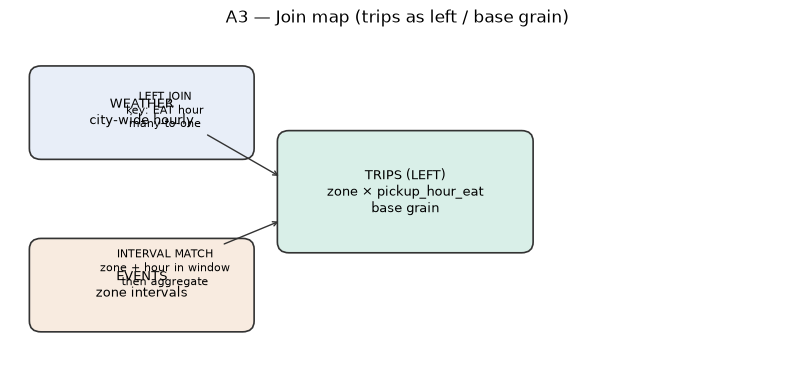

saved: ../figures/A3_join_map.png


In [83]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.5)
ax.axis("off")
ax.set_title("A3 — Join map (trips as left / base grain)", fontsize=12, pad=8)

def box(x, y, w, h, text, color):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.15",
                       facecolor=color, edgecolor="#333", linewidth=1.2)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9)

box(3.5, 1.5, 3.2, 1.6, "TRIPS (LEFT)\nzone × pickup_hour_eat\nbase grain", "#d9efe8")
box(0.3, 2.8, 2.8, 1.2, "WEATHER\ncity-wide hourly", "#e8eef8")
box(0.3, 0.4, 2.8, 1.2, "EVENTS\nzone intervals", "#f8ebe0")

ax.annotate(
    "LEFT JOIN\nkey: EAT hour\nmany-to-one",
    xy=(3.5, 2.5), xytext=(2.0, 3.2),
    fontsize=8, ha="center",
    arrowprops=dict(arrowstyle="->", color="#333"),
)
ax.annotate(
    "INTERVAL MATCH\nzone + hour in window\nthen aggregate",
    xy=(3.5, 1.9), xytext=(2.0, 1.0),
    fontsize=8, ha="center",
    arrowprops=dict(arrowstyle="->", color="#333"),
)

fig_path = ROOT / "figures" / "A3_join_map.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=140, bbox_inches="tight")
plt.show()
print("saved:", fig_path)


#### Keys, join type, cardinality


In [84]:
from cleaning import EVENT_WINDOW, DEFAULT_WINDOW

join_map = pd.DataFrame(
    [
        {
            "join": "trips ← weather",
            "left": "trips (zone × hour)",
            "right": "weather (one row per hour)",
            "keys": "pickup_hour_eat = timestamp_eat",
            "join_type": "left join",
            "cardinality": "many-to-one",
            "why_left": "Forecast grain is zone-hour; weather is city-wide context",
        },
        {
            "join": "trips ← events",
            "left": "trips (zone × hour)",
            "right": "events (start/end + pre/post window)",
            "keys": "zone match AND pickup_hour_eat ∈ [window_start, window_end]",
            "join_type": "interval match → aggregate",
            "cardinality": "many-to-many then 1 row/zone-hour",
            "why_left": "Keep one prediction row; collapse overlapping events to flags/counts",
        },
    ]
)
join_map


,join,left,right,keys,join_type,cardinality,why_left
0,trips ← weather,trips (zone × hour),weather (one row per hour),pickup_hour_eat = timestamp_eat,left join,many-to-one,Forecast grain is zone-hour; weather is city-w...
1,trips ← events,trips (zone × hour),events (start/end + pre/post window),zone match AND pickup_hour_eat ∈ [window_start...,interval match → aggregate,many-to-many then 1 row/zone-hour,Keep one prediction row; collapse overlapping ...


#### Event window rule

Demand can move **before** an event starts and **after** it ends. Window =  
`[start − pre_hours, end + post_hours]` (EAT). Only **confirmed** events are joined.


In [85]:
window_tbl = pd.DataFrame(
    [
        {
            "event_type": t,
            "pre_hours": pre,
            "post_hours": post,
            "rationale": rationale,
        }
        for t, (pre, post), rationale in [
            ("football_match", EVENT_WINDOW["football_match"], "Arrival/departure crowds around kickoff"),
            ("concert", EVENT_WINDOW["concert"], "Ingress before; egress after show"),
            ("sports_run", EVENT_WINDOW["sports_run"], "Short pre/post for race logistics"),
            ("conference", EVENT_WINDOW["conference"], "Effect mostly during scheduled hours"),
            ("exhibition", EVENT_WINDOW["exhibition"], "Effect mostly during open hours"),
            ("road_closure", EVENT_WINDOW["road_closure"], "Use listed closure interval only"),
            ("public_holiday", EVENT_WINDOW["public_holiday"], "Calendar day effect; no extra buffer"),
            ("school_break", EVENT_WINDOW["school_break"], "Multi-day regime; no extra buffer"),
        ]
    ]
)
print(f"Default window for any other type: {DEFAULT_WINDOW}")
window_tbl


Default window for any other type: (1, 1)


,event_type,pre_hours,post_hours,rationale
0,football_match,2,2,Arrival/departure crowds around kickoff
1,concert,1,2,Ingress before; egress after show
2,sports_run,1,1,Short pre/post for race logistics
3,conference,0,0,Effect mostly during scheduled hours
4,exhibition,0,0,Effect mostly during open hours
5,road_closure,0,0,Use listed closure interval only
6,public_holiday,0,0,Calendar day effect; no extra buffer
7,school_break,0,0,Multi-day regime; no extra buffer


#### Why trips is the left table

1. **Target grain** — we forecast `trips` for every zone-hour (train history + test grid).  
2. **Weather is many-to-one** — one city weather row fans out to 12 zones; left-joining from trips keeps row count stable.  
3. **Events are intervals** — matching from each zone-hour into event windows, then aggregating, avoids exploding the base table.

Weather/events are never used as the left/base table for the master modeling frame.


#### A3 summary

| Piece | Choice |
|-------|--------|
| Left / base | **Trips** (zone × `pickup_hour_eat`) |
| Weather | Left join on EAT hour — **many-to-one** |
| Events | Interval match on zone + window — aggregate back to zone-hour |
| Event window | Type-specific pre/post hours (table above); confirmed only |

**A3 done.** Next: A4 join audit (match rates, row counts).


### A4–A8 — Join, features, checks, master tables

Simple path: build once with `src/cleaning.py` + `src/features.py` (or `scripts/build_masters.py`), then show the graded outputs below.


In [86]:
# Build joined + featured masters (one run)
from cleaning import build_joined_tables, CANONICAL_ZONES
from features import add_features, feature_dictionary, FEATURE_SPEC

parts = build_joined_tables()
trips_train = parts["trips_train"]
trips_test = parts["trips_test"]
weather_c = parts["weather"]
events_c = parts["events"]
train_joined = parts["train_joined"]
test_joined = parts["test_joined"]

master_train = add_features(train_joined, train_trips_history=trips_train)
master_test = add_features(test_joined, train_trips_history=trips_train).drop(columns=["trips"], errors="ignore")

print("train_joined", train_joined.shape, "test_joined", test_joined.shape)
print("master_train", master_train.shape, "master_test", master_test.shape)


train_joined (84614, 20) test_joined (4032, 16)
master_train (84614, 29) master_test (4032, 25)


### A4 — Join audit


In [87]:
# Weather join audit
before_w = len(trips_train)
after_w = len(train_joined)
w_keys = set(weather_c["timestamp_eat"])
miss_mask = ~trips_train["pickup_hour_eat"].isin(w_keys)
n_miss = int(miss_mask.sum())
n_miss_hours = int(trips_train.loc[miss_mask, "pickup_hour_eat"].nunique())

weather_audit = pd.DataFrame(
    [
        {"metric": "rows before join", "value": before_w},
        {"metric": "rows after join", "value": after_w},
        {"metric": "row count unchanged?", "value": before_w == after_w},
        {"metric": "match rate before fill (%)", "value": round(100 * (1 - n_miss / before_w), 2)},
        {"metric": "zone-hours with no weather key", "value": n_miss},
        {"metric": "unique missing weather hours", "value": n_miss_hours},
        {"metric": "null rain after fill", "value": int(train_joined["rain_mm"].isna().sum())},
        {"metric": "treatment", "value": "ffill/bfill on city hour after left join"},
    ]
)
print("Why missing weather keys? Gaps in weather_hourly after dedupe (not outside date range).")
weather_audit


Why missing weather keys? Gaps in weather_hourly after dedupe (not outside date range).


,metric,value
0,rows before join,84614
1,rows after join,84614
2,row count unchanged?,True
3,match rate before fill (%),89.07
4,zone-hours with no weather key,9249
5,unique missing weather hours,790
6,null rain after fill,0
7,treatment,ffill/bfill on city hour after left join


In [88]:
# Events join audit
confirmed = events_c[events_c["status_clean"].str.contains("confirm", na=False)]
cancelled = events_c[~events_c["status_clean"].str.contains("confirm", na=False)]
matched_ids = set()
for s in train_joined.loc[train_joined["n_events"] > 0, "matched_event_ids"]:
    if s:
        matched_ids.update(s.split(","))
all_conf = set(confirmed["event_id"].astype(str))
unmatched = sorted(all_conf - matched_ids)

events_audit = pd.DataFrame(
    [
        {"metric": "rows before / after events join", "value": f"{before_w} / {len(train_joined)}"},
        {"metric": "confirmed event ids", "value": int(confirmed["event_id"].nunique())},
        {"metric": "cancelled event-zone rows (excluded)", "value": int(len(cancelled))},
        {"metric": "events matched ≥1 zone-hour", "value": len(matched_ids)},
        {"metric": "confirmed events unmatched", "value": len(unmatched)},
        {"metric": "unmatched ids (sample)", "value": ", ".join(unmatched[:8]) if unmatched else "—"},
        {"metric": "zone-hours with n_events>0", "value": int((train_joined["n_events"] > 0).sum())},
    ]
)
print("Excluded from features: cancelled status. Unmatched usually means no overlapping train zone-hours.")
events_audit


Excluded from features: cancelled status. Unmatched usually means no overlapping train zone-hours.


,metric,value
0,rows before / after events join,84614 / 84614
1,confirmed event ids,159
2,cancelled event-zone rows (excluded),6
3,events matched ≥1 zone-hour,153
4,confirmed events unmatched,6
5,unmatched ids (sample),"EVT-0030, EVT-0085, EVT-0138, EVT-0139, EVT-01..."
6,zone-hours with n_events>0,80442


### A5 — Join proof (3 zone-hours)


In [89]:
# Pick one rainy hour, one football window, one public holiday
ex_rain = master_train.loc[master_train["rain_mm"] >= 2].iloc[0]
ex_foot = master_train.loc[master_train["is_football_window"] == 1].iloc[0]
ex_hol = master_train.loc[master_train["is_public_holiday"] == 1].iloc[0]

cols = [
    "zone", "pickup_hour_eat", "trips",
    "temp_c", "rain_mm", "rain_class", "rain_last_3h",
    "in_event_window", "is_football_window", "is_public_holiday",
    "n_events", "event_attendance", "hours_to_event_start", "matched_event_ids",
]

proof = pd.DataFrame(
    [
        {"case": "rain", **ex_rain[cols].to_dict()},
        {"case": "football window", **ex_foot[cols].to_dict()},
        {"case": "public holiday", **ex_hol[cols].to_dict()},
    ]
)

# Attach the weather row used (same EAT hour)
for i, row in proof.iterrows():
    wrow = weather_c.loc[weather_c["timestamp_eat"] == row["pickup_hour_eat"]]
    proof.loc[i, "weather_rows_matched"] = len(wrow)

proof


,case,zone,pickup_hour_eat,trips,temp_c,rain_mm,rain_class,rain_last_3h,in_event_window,is_football_window,is_public_holiday,n_events,event_attendance,hours_to_event_start,matched_event_ids,weather_rows_matched
0,rain,Arat Kilo,2025-01-02 19:00:00+03:00,77.0,15.4,5.7,3,6.2,0,0,0,0,NaN,NaN,,1.0
1,football window,Kazanchis,2025-01-19 13:00:00+03:00,36.0,22.2,0.0,0,0.0,1,1,1,5,16007.0,-325.016667,"EVT-0001,EVT-0003,EVT-0004,EVT-0055,EVT-9001",1.0
2,public holiday,Arat Kilo,2025-01-06 00:00:00+03:00,3.0,9.0,0.0,0,0.0,1,0,1,1,NaN,-0.016667,EVT-0055,1.0


### A6 — Feature engineering table

≥8 features: ≥3 calendar, ≥2 weather, ≥3 events, ≥1 lag/trend. All marked known-at-forecast-time.


In [90]:
feat_tbl = feature_dictionary()[
    ["name", "formula", "source", "why", "known_at_forecast_time", "group"]
]
print(feat_tbl.groupby("group").size())
assert (feat_tbl["group"] == "calendar").sum() >= 3
assert (feat_tbl["group"] == "weather").sum() >= 2
assert (feat_tbl["group"] == "events").sum() >= 3
assert (feat_tbl["group"] == "lag").sum() >= 1
assert len(feat_tbl) >= 8
feat_tbl.to_csv(ROOT / "reports" / "A6_feature_table.csv", index=False)
feat_tbl


group
calendar    5
events      4
lag         2
weather     3
dtype: int64


,name,formula,source,why,known_at_forecast_time,group
0,hour,hour of pickup_hour_eat,pickup_hour_eat,Demand has strong daily seasonality,yes,calendar
1,dow,day of week 0=Mon … 6=Sun,pickup_hour_eat,Weekday vs weekend patterns differ by zone,yes,calendar
2,is_weekend,"1 if dow in {5,6}",dow,"Weekend demand shifts (markets, leisure)",yes,calendar
3,is_payday_window,1 if day_of_month <=3 or >=28,pickup_hour_eat,Pay-period spending may lift trips,yes,calendar
4,is_public_holiday,1 if hour overlaps a confirmed public_holiday ...,events,Holidays change city-wide demand,yes,calendar
5,rain_mm,cleaned rain in the hour,weather.rain_mm,Rain often increases ride requests,yes,weather
6,rain_last_3h,rain_mm + lag1 + lag2 (by city hour),weather.rain_mm,Wet conditions persist beyond a single hour,yes,weather
7,rain_class,0 none / 1 light / 2 moderate / 3 heavy,rain_mm,Non-linear rain response,yes,weather
8,in_event_window,1 if any confirmed event window covers the hour,events,Events create local demand spikes,yes,events
9,is_football_window,1 if football_match window (±2h) covers the hour,events,Matches are among the largest local shocks,yes,events


### A7 — Integrity checks


In [91]:
def run_integrity_checks(train: pd.DataFrame, test: pd.DataFrame, train_n: int, test_n: int):
    checks = []

    def add(name, ok):
        checks.append((name, bool(ok)))
        print(f"[{'PASS' if ok else 'FAIL'}] {name}")

    add("one row per zone-hour (train)", not train.duplicated(["zone", "pickup_hour_eat"]).any())
    add("one row per zone-hour (test)", not test.duplicated(["zone", "pickup_hour_eat"]).any())
    add("join did not change train row count", len(train) == train_n)
    add("join did not change test row count", len(test) == test_n)
    add("only 12 zone labels", set(train["zone"]) | set(test["zone"]) <= set(CANONICAL_ZONES))
    add("timestamps on Africa/Addis_Ababa", str(train["pickup_hour_eat"].dt.tz) == "Africa/Addis_Ababa")
    add("no negative trips", not (train["trips"] < 0).any())
    add("no rain sentinel -9999", not ((train["rain_mm"] == -9999).any() or (test["rain_mm"] == -9999).any()))
    feat_names = [f["name"] for f in FEATURE_SPEC]
    add("train/test share engineered feature columns", all(c in train.columns and c in test.columns for c in feat_names))
    add("test has no target", "trips" not in test.columns)
    add("feature list has no ops leakage cols", {"avg_fare_birr", "avg_wait_min", "active_drivers"}.isdisjoint(feat_names))
    return checks

integrity = run_integrity_checks(master_train, master_test, len(trips_train), len(trips_test))
(ROOT / "reports" / "A7_integrity_checks.txt").write_text(
    "\n".join(f"[{'PASS' if ok else 'FAIL'}] {name}" for name, ok in integrity) + "\n"
)


[PASS] one row per zone-hour (train)
[PASS] one row per zone-hour (test)
[PASS] join did not change train row count
[PASS] join did not change test row count
[PASS] only 12 zone labels
[PASS] timestamps on Africa/Addis_Ababa
[PASS] no negative trips
[PASS] no rain sentinel -9999
[PASS] train/test share engineered feature columns
[PASS] test has no target
[PASS] feature list has no ops leakage cols


401

### A8 — Master tables & data dictionary


In [92]:
# Export master_train / master_test / data_dictionary_master
PROCESSED.mkdir(parents=True, exist_ok=True)

def _export(df):
    out = df.copy()
    out["pickup_hour_eat"] = out["pickup_hour_eat"].dt.tz_convert("Africa/Addis_Ababa").dt.strftime("%Y-%m-%d %H:%M:%S%z")
    return out

dd = pd.DataFrame(
    [
        {"column": "zone", "type": "category", "source": "trips", "description": "Canonical zone", "derived": "normalize_zone_label"},
        {"column": "pickup_hour_eat", "type": "datetime(tz)", "source": "trips", "description": "EAT hour", "derived": "parse_trip_hour"},
        {"column": "trips", "type": "float", "source": "trips", "description": "Target (train only)", "derived": "clean+impute"},
        {"column": "temp_c", "type": "float", "source": "weather", "description": "Temperature C", "derived": "join_weather"},
        {"column": "rain_mm", "type": "float", "source": "weather", "description": "Rain mm", "derived": "join_weather"},
        {"column": "humidity_pct", "type": "float", "source": "weather", "description": "Humidity", "derived": "join_weather"},
        {"column": "wind_kmh", "type": "float", "source": "weather", "description": "Wind", "derived": "join_weather"},
        {"column": "n_events", "type": "int", "source": "events", "description": "Matched events", "derived": "join_events"},
        {"column": "matched_event_ids", "type": "string", "source": "events", "description": "Event ids", "derived": "join_events"},
    ]
    + [
        {
            "column": f["name"],
            "type": "engineered",
            "source": f["source"],
            "description": f["why"],
            "derived": f["formula"],
        }
        for f in FEATURE_SPEC
    ]
)

_export(master_train).to_csv(PROCESSED / "master_train.csv", index=False)
_export(master_test).to_csv(PROCESSED / "master_test.csv", index=False)
dd.to_csv(PROCESSED / "data_dictionary_master.csv", index=False)

print("Saved:")
print(" ", PROCESSED / "master_train.csv", master_train.shape)
print(" ", PROCESSED / "master_test.csv", master_test.shape)
print(" ", PROCESSED / "data_dictionary_master.csv", dd.shape)
dd.head(12)


Saved:
  ../data/processed/master_train.csv (84614, 29)
  ../data/processed/master_test.csv (4032, 25)
  ../data/processed/data_dictionary_master.csv (23, 5)


,column,type,source,description,derived
0,zone,category,trips,Canonical zone,normalize_zone_label
1,pickup_hour_eat,datetime(tz),trips,EAT hour,parse_trip_hour
2,trips,float,trips,Target (train only),clean+impute
3,temp_c,float,weather,Temperature C,join_weather
4,rain_mm,float,weather,Rain mm,join_weather
5,humidity_pct,float,weather,Humidity,join_weather
6,wind_kmh,float,weather,Wind,join_weather
7,n_events,int,events,Matched events,join_events
8,matched_event_ids,string,events,Event ids,join_events
9,hour,engineered,pickup_hour_eat,Demand has strong daily seasonality,hour of pickup_hour_eat


#### A4–A8 done

| ID | Output |
|----|--------|
| A4 | Join audits (weather + events) above; `reports/A4_join_audit.csv` |
| A5 | 3 example zone-hours with attached weather/event features |
| A6 | Feature table (`reports/A6_feature_table.csv`) |
| A7 | PASS/FAIL checks (`reports/A7_integrity_checks.txt`) |
| A8 | `data/processed/master_train.csv`, `master_test.csv`, `data_dictionary_master.csv` |

Or rebuild from CLI: `python scripts/build_masters.py`
